--- INITIALIZING FULL ARCHITECTURE COMBINATION ---
1. Loading True Labels...
2. Loading Branch A (RoBERTa)...
3. Loading Branch B (XGBoost Probabilities)...
4. Loading Branch B (Numerical Metadata X_ml)...

--- FUSION LAYER ---
Fusion Layer Complete! Shape: (32345, 775) (Should be 775)

Applying Standard Scaling...

--- OPTIMIZATION LAYER ---
Searching for the optimal Neural Network configuration (This may take a minute)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Optimization Complete!
Best Configuration Found: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (64, 16), 'alpha': 0.1, 'activation': 'relu'}

--- FINAL OUTPUT LAYER ---
          FINAL ARCHITECTURE RESULTS           
Final Accuracy : 94.47%
Final F1 Score : 94.47%

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.94      0.95      0.95      4044
        Fake       0.95      0.94      0.94      4043

    accuracy                           0.94      8

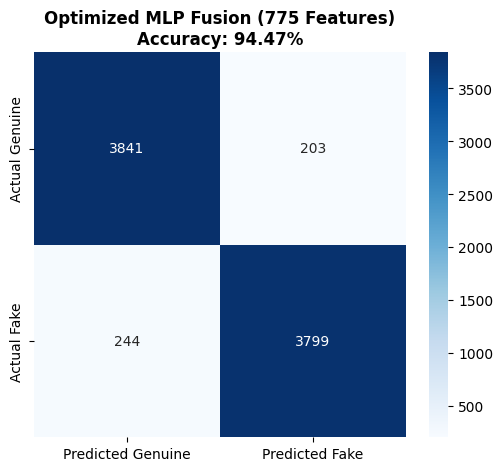

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INITIALIZING FULL ARCHITECTURE COMBINATION ---")

print("1. Loading True Labels...")
# We can grab the labels directly from your new num_data files!
y_train = pd.read_csv('train_num_data.csv')['label'].values
y_test = pd.read_csv('test_num_data.csv')['label'].values

print("2. Loading Branch A (RoBERTa)...")
# h_transformer (768 Embeddings)
train_h_trans = torch.load('train_roberta_embeddings.pt').numpy()
test_h_trans = torch.load('test_roberta_embeddings.pt').numpy()

# p_tr (RoBERTa Probability)
train_p_tr = pd.read_csv('train_roberta_probabilities.csv')['roberta_prob'].values.reshape(-1, 1)
test_p_tr = pd.read_csv('test_roberta_probabilities.csv')['roberta_prob'].values.reshape(-1, 1)

print("3. Loading Branch B (XGBoost Probabilities)...")
# p_ml (XGBoost Probability)
train_p_ml = pd.read_csv('train_xgb_probabilities.csv')['xgb_prob'].values.reshape(-1, 1)
test_p_ml = pd.read_csv('test_xgb_probabilities.csv')['xgb_prob'].values.reshape(-1, 1)

print("4. Loading Branch B (Numerical Metadata X_ml)...")
# X_ml (The 5 raw numerical features)
num_cols = ['char_count', 'word_count', 'punct_density', 'cap_ratio', 'rating']
train_xml = pd.read_csv('train_num_data.csv')[num_cols].fillna(0).values
test_xml = pd.read_csv('test_num_data.csv')[num_cols].fillna(0).values

print("\n--- FUSION LAYER ---")
# Concatenate: [h_transformer, p_tr, p_ml, X_ml] = 768 + 1 + 1 + 5 = 775 Features!
X_train_fusion = np.hstack((train_h_trans, train_p_tr, train_p_ml, train_xml))
X_test_fusion = np.hstack((test_h_trans, test_p_tr, test_p_ml, test_xml))

print(f"Fusion Layer Complete! Shape: {X_train_fusion.shape} (Should be 775)")

print("\nApplying Standard Scaling...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fusion)
X_test_scaled = scaler.transform(X_test_fusion)

print("\n--- OPTIMIZATION LAYER ---")
print("Searching for the optimal Neural Network configuration (This may take a minute)...")

# Define the Base Meta-Classifier
base_mlp = MLPClassifier(max_iter=300, early_stopping=True, random_state=42)

# Define the Hyperparameter Search Space
param_distributions = {
    'hidden_layer_sizes': [(256, 64), (128, 32), (64, 16)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.001, 0.01, 0.1],      # L2 Regularization (Dropout equivalent)
    'learning_rate_init': [0.001, 0.005]
}

# Wrap the Optimizer around the model
optimizer = RandomizedSearchCV(
    estimator=base_mlp,
    param_distributions=param_distributions,
    n_iter=10,             # Tests 10 different layer/dropout combinations
    scoring='accuracy',
    cv=3,                  # 3-Fold Cross Validation
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Run the Optimization
optimizer.fit(X_train_scaled, y_train)

print(f"\n Optimization Complete!")
print(f"Best Configuration Found: {optimizer.best_params_}")

print("\n--- FINAL OUTPUT LAYER ---")
# Extract the best model and evaluate
best_meta_classifier = optimizer.best_estimator_
final_predictions = best_meta_classifier.predict(X_test_scaled)

# Calculate final metrics
acc = accuracy_score(y_test, final_predictions)
f1 = f1_score(y_test, final_predictions, average='macro')

print("=========================================")
print("          FINAL ARCHITECTURE RESULTS           ")
print("=========================================")
print(f"Final Accuracy : {acc * 100:.2f}%")
print(f"Final F1 Score : {f1 * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, final_predictions, target_names=['Genuine', 'Fake']))

# Plotting the Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Genuine', 'Predicted Fake'],
            yticklabels=['Actual Genuine', 'Actual Fake'])
plt.title(f'Optimized MLP Fusion (775 Features)\nAccuracy: {acc * 100:.2f}%', fontweight='bold')
plt.show()

--- 1. LOADING ALL PROBABILITIES AND METADATA ---
--- 2. BUILDING THE FUSION MATRIX ---
Fusion Train Matrix Shape: (32345, 7) (Should have 7 columns)

--- 3. TRAINING THE MLP META-CLASSIFIER ---

--- 4. FINAL EVALUATION ---
          MLP NEURAL FUSION RESULTS            
Final Accuracy : 95.07%
Final F1 Score : 95.07%

Classification Report:
              precision    recall  f1-score   support

        Fake       0.96      0.94      0.95      4044
     Genuine       0.95      0.96      0.95      4043

    accuracy                           0.95      8087
   macro avg       0.95      0.95      0.95      8087
weighted avg       0.95      0.95      0.95      8087



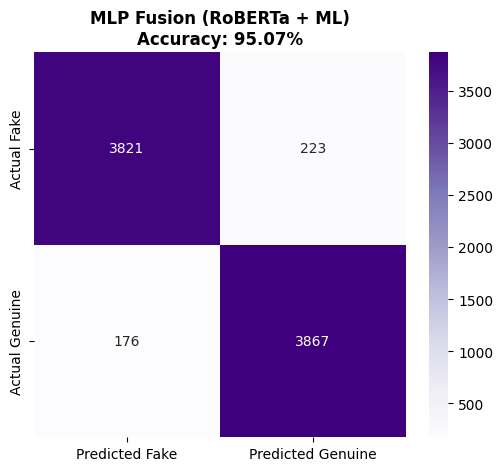

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("--- 1. LOADING ALL PROBABILITIES AND METADATA ---")

# Load True Labels & Numerical Data
df_train_num = pd.read_csv('train_num_data.csv')
df_test_num = pd.read_csv('test_num_data.csv')

y_train = df_train_num['label'].values
y_test = df_test_num['label'].values

# Load 5 Numerical Features
num_cols = ['char_count', 'word_count', 'punct_density', 'cap_ratio', 'rating']
X_train_num = df_train_num[num_cols].fillna(0).values
X_test_num = df_test_num[num_cols].fillna(0).values

# Scale the numerical features (Critical for Neural Networks!)
scaler_num = StandardScaler()
X_train_num_scaled = scaler_num.fit_transform(X_train_num)
X_test_num_scaled = scaler_num.transform(X_test_num)

# Load Branch A: RoBERTa Probabilities
# Ensure your column name matches what your RoBERTa script outputs (e.g., 'roberta_prob')
train_rob_prob = pd.read_csv('train_roberta_probabilities.csv')['roberta_prob'].values.reshape(-1, 1)
test_rob_prob = pd.read_csv('test_roberta_probabilities.csv')['roberta_prob'].values.reshape(-1, 1)

# Load Branch B: Logistic Regression Probabilities
train_lr_prob = pd.read_csv('train_lr_probabilities.csv')['lr_prob'].values.reshape(-1, 1)
test_lr_prob = pd.read_csv('test_lr_probabilities.csv')['lr_prob'].values.reshape(-1, 1)

print("--- 2. BUILDING THE FUSION MATRIX ---")
# Stack: [RoBERTa Prob, LR Prob, char_count, word_count, punct_density, cap_ratio, rating]
X_train_fusion = np.hstack((train_rob_prob, train_lr_prob, X_train_num_scaled))
X_test_fusion = np.hstack((test_rob_prob, test_lr_prob, X_test_num_scaled))

print(f"Fusion Train Matrix Shape: {X_train_fusion.shape} (Should have 7 columns)")

print("\n--- 3. TRAINING THE MLP META-CLASSIFIER ---")
# We use a small architecture (16 nodes -> 8 nodes) to prevent overfitting on just 7 features
# L2 Regularization (alpha=0.01) is added to keep the network from memorizing the training data
mlp_fusion = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=500,
    random_state=42,
    early_stopping=True # Stops training automatically when validation score stops improving
)

mlp_fusion.fit(X_train_fusion, y_train)

print("\n--- 4. FINAL EVALUATION ---")
final_predictions = mlp_fusion.predict(X_test_fusion)

acc = accuracy_score(y_test, final_predictions)
f1 = f1_score(y_test, final_predictions, average='macro')

print(" ========================================= ")
print("          MLP NEURAL FUSION RESULTS            ")
print(" ========================================= ")
print(f"Final Accuracy : {acc * 100:.2f}%")
print(f"Final F1 Score : {f1 * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, final_predictions, target_names=['Fake', 'Genuine']))

# Plotting the Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted Fake', 'Predicted Genuine'],
            yticklabels=['Actual Fake', 'Actual Genuine'])
plt.title(f'MLP Fusion (RoBERTa + ML)\nAccuracy: {acc * 100:.2f}%', fontweight='bold')
plt.show()

--- 1. LOADING FUSION DATA ---

--- 2. ARTIFICIAL BEE COLONY (ABC) OPTIMIZATION ---
Starting the Swarm Search... (This will take a minute or two)
Iteration 1/10 | Best CV Accuracy found so far: 97.96%
Iteration 2/10 | Best CV Accuracy found so far: 97.96%
Iteration 3/10 | Best CV Accuracy found so far: 97.96%
Iteration 4/10 | Best CV Accuracy found so far: 97.96%
Iteration 5/10 | Best CV Accuracy found so far: 97.96%
Iteration 6/10 | Best CV Accuracy found so far: 97.96%
Iteration 7/10 | Best CV Accuracy found so far: 97.96%
Iteration 8/10 | Best CV Accuracy found so far: 97.96%
Iteration 9/10 | Best CV Accuracy found so far: 97.96%
Iteration 10/10 | Best CV Accuracy found so far: 97.96%

🐝 ABC Swarm Optimization Complete! 🐝
Optimal n_estimators: 154
Optimal max_depth: 4
Optimal learning_rate: 0.0926
Optimal subsample: 0.8378
Optimal colsample_bytree: 0.7025

--- 3. TRAINING FINAL XGBOOST WITH ABC PARAMETERS ---
🏆 ========================================= 🏆
        ABC-OPTIMIZED XGBOOS

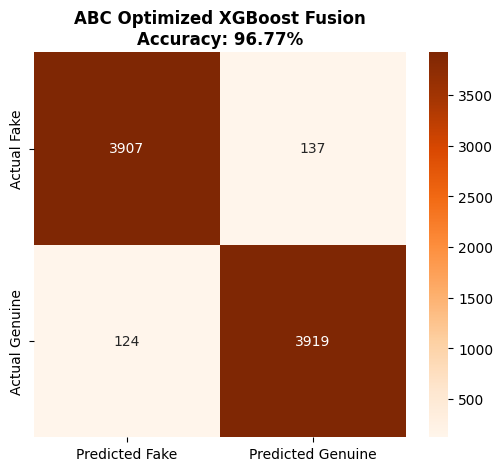

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("--- 1. LOADING FUSION DATA ---")

# Load True Labels & Numerical Data
df_train_num = pd.read_csv('train_num_data.csv')
df_test_num = pd.read_csv('test_num_data.csv')

y_train = df_train_num['label'].values
y_test = df_test_num['label'].values

# Load and scale Numerical Features
num_cols = ['char_count', 'word_count', 'punct_density', 'cap_ratio', 'rating']
scaler_num = StandardScaler()
X_train_num_scaled = scaler_num.fit_transform(df_train_num[num_cols].fillna(0).values)
X_test_num_scaled = scaler_num.transform(df_test_num[num_cols].fillna(0).values)

# Load Probabilities
train_rob_prob = pd.read_csv('train_roberta_probabilities.csv')['roberta_prob'].values.reshape(-1, 1)
test_rob_prob = pd.read_csv('test_roberta_probabilities.csv')['roberta_prob'].values.reshape(-1, 1)

train_lr_prob = pd.read_csv('train_lr_probabilities.csv')['lr_prob'].values.reshape(-1, 1)
test_lr_prob = pd.read_csv('test_lr_probabilities.csv')['lr_prob'].values.reshape(-1, 1)

# Build Fusion Matrix
X_train_fusion = np.hstack((train_rob_prob, train_lr_prob, X_train_num_scaled))
X_test_fusion = np.hstack((test_rob_prob, test_lr_prob, X_test_num_scaled))

print("\n--- 2. ARTIFICIAL BEE COLONY (ABC) OPTIMIZATION ---")

# Hyperparameter Bounds: [min, max]
# [n_estimators, max_depth, learning_rate, subsample, colsample_bytree]
bounds = [
    (50, 300),      # n_estimators (Integer)
    (2, 8),         # max_depth (Integer)
    (0.01, 0.3),    # learning_rate (Float)
    (0.5, 1.0),     # subsample (Float)
    (0.5, 1.0)      # colsample_bytree (Float)
]

def fitness_function(params):
    """Evaluates how good a specific hyperparameter combination is using Cross-Validation."""
    model = xgb.XGBClassifier(
        n_estimators=int(params[0]),
        max_depth=int(params[1]),
        learning_rate=params[2],
        subsample=params[3],
        colsample_bytree=params[4],
        random_state=42,
        eval_metric='logloss'
    )
    # 3-Fold CV ensures the bees find parameters that actually generalize well
    return cross_val_score(model, X_train_fusion, y_train, cv=3, scoring='accuracy').mean()

# ABC Settings
colony_size = 10
max_iter = 3
limit = 3 # If a food source doesn't improve after 3 tries, scout bees replace it

# Initialize Food Sources (Random Hyperparameters)
def init_food_source():
    return [
        random.randint(bounds[0][0], bounds[0][1]),
        random.randint(bounds[1][0], bounds[1][1]),
        random.uniform(bounds[2][0], bounds[2][1]),
        random.uniform(bounds[3][0], bounds[3][1]),
        random.uniform(bounds[4][0], bounds[4][1])
    ]

food_sources = [init_food_source() for _ in range(colony_size)]
fitness = [fitness_function(fs) for fs in food_sources]
trials = [0] * colony_size

best_food_source = food_sources[np.argmax(fitness)]
best_fitness = max(fitness)

print("Starting the Swarm Search... (This will take a;  minute or two)")

for iteration in range(max_iter):
    # Employed Bees Phase
    for i in range(colony_size):
        partner = random.choice([x for x in range(colony_size) if x != i])
        param_to_change = random.randint(0, 4)

        new_source = food_sources[i].copy()
        phi = random.uniform(-1, 1)
        new_source[param_to_change] = new_source[param_to_change] + phi * (new_source[param_to_change] - food_sources[partner][param_to_change])

        # Enforce Bounds
        if param_to_change in [0, 1]: # Integer parameters
            new_source[param_to_change] = int(np.clip(new_source[param_to_change], bounds[param_to_change][0], bounds[param_to_change][1]))
        else: # Float parameters
            new_source[param_to_change] = np.clip(new_source[param_to_change], bounds[param_to_change][0], bounds[param_to_change][1])

        new_fitness = fitness_function(new_source)
        if new_fitness > fitness[i]:
            food_sources[i] = new_source
            fitness[i] = new_fitness
            trials[i] = 0
        else:
            trials[i] += 1

    # Onlooker Bees Phase (Tournament Selection based on fitness)
    probabilities = [f / sum(fitness) for f in fitness]
    for _ in range(colony_size):
        i = np.random.choice(range(colony_size), p=probabilities)
        partner = random.choice([x for x in range(colony_size) if x != i])
        param_to_change = random.randint(0, 4)

        new_source = food_sources[i].copy()
        phi = random.uniform(-1, 1)
        new_source[param_to_change] = new_source[param_to_change] + phi * (new_source[param_to_change] - food_sources[partner][param_to_change])

        # Enforce Bounds
        if param_to_change in [0, 1]:
            new_source[param_to_change] = int(np.clip(new_source[param_to_change], bounds[param_to_change][0], bounds[param_to_change][1]))
        else:
            new_source[param_to_change] = np.clip(new_source[param_to_change], bounds[param_to_change][0], bounds[param_to_change][1])

        new_fitness = fitness_function(new_source)
        if new_fitness > fitness[i]:
            food_sources[i] = new_source
            fitness[i] = new_fitness
            trials[i] = 0
        else:
            trials[i] += 1

    # Scout Bees Phase
    for i in range(colony_size):
        if trials[i] > limit:
            food_sources[i] = init_food_source()
            fitness[i] = fitness_function(food_sources[i])
            trials[i] = 0

    # Update Best Solution
    if max(fitness) > best_fitness:
        best_fitness = max(fitness)
        best_food_source = food_sources[np.argmax(fitness)]

    print(f"Iteration {iteration + 1}/{max_iter} | Best CV Accuracy found so far: {best_fitness * 100:.2f}%")

print("\n🐝 ABC Swarm Optimization Complete! 🐝")
print(f"Optimal n_estimators: {int(best_food_source[0])}")
print(f"Optimal max_depth: {int(best_food_source[1])}")
print(f"Optimal learning_rate: {best_food_source[2]:.4f}")
print(f"Optimal subsample: {best_food_source[3]:.4f}")
print(f"Optimal colsample_bytree: {best_food_source[4]:.4f}")

print("\n--- 3. TRAINING FINAL XGBOOST WITH ABC PARAMETERS ---")
final_xgb = xgb.XGBClassifier(
    n_estimators=int(best_food_source[0]),
    max_depth=int(best_food_source[1]),
    learning_rate=best_food_source[2],
    subsample=best_food_source[3],
    colsample_bytree=best_food_source[4],
    random_state=42,
    eval_metric='logloss'
)

final_xgb.fit(X_train_fusion, y_train)

final_preds = final_xgb.predict(X_test_fusion)
acc = accuracy_score(y_test, final_preds)
f1 = f1_score(y_test, final_preds, average='macro')

print("🏆 ========================================= 🏆")
print("        ABC-OPTIMIZED XGBOOST RESULTS          ")
print("🏆 ========================================= 🏆")
print(f"Final Test Accuracy : {acc * 100:.2f}%")
print(f"Final Test F1 Score : {f1 * 100:.2f}%\n")

# Plotting the Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted Fake', 'Predicted Genuine'],
            yticklabels=['Actual Fake', 'Actual Genuine'])
plt.title(f'ABC Optimized XGBoost Fusion\nAccuracy: {acc * 100:.2f}%', fontweight='bold')
plt.show()

In [ ]:
import joblib

print("--- SAVING THE FINAL PIPELINE ---")

# 1. Save the XGBoost Fusion Model natively
final_xgb.save_model("abc_xgboost_fusion_model.json")
print("✅ XGBoost Fusion Model safely saved as 'abc_xgboost_fusion_model.json'")

# 2. Save the Numerical Scaler (CRITICAL for future predictions)
joblib.dump(scaler_num, "numerical_scaler.pkl")
print("✅ Numerical Scaler safely saved as 'numerical_scaler.pkl'")

print("\n🎉 Your complete, state-of-the-art Fake Review Detection Pipeline is now fully backed up and ready for deployment!")

--- SAVING THE FINAL PIPELINE ---
✅ XGBoost Fusion Model safely saved as 'abc_xgboost_fusion_model.json'
✅ Numerical Scaler safely saved as 'numerical_scaler.pkl'

🎉 Your complete, state-of-the-art Fake Review Detection Pipeline is now fully backed up and ready for deployment!
